# IMPORT LIBRARY

In [152]:

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms
from torchvision import datasets



from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

from tqdm import tqdm

# Device setting and Dataset directory

In [153]:
if torch.backends.mps.is_available():

    DEVICE = torch.device("mps")

else:

    DEVICE = torch.device("cpu")

print("Using Device:", DEVICE)


# PATHS


TRAIN_DIR = "./cifar10/train"

TEST_DIR = "./cifar10/test"

Using Device: mps



# Necessary Settings for model

In [154]:
IMG_SIZE = 128

BATCH_SIZE = 16

EPOCHS = 30

LR = 1e-4

WEIGHT_DECAY = 1e-4

PATIENCE = 7

LABEL_SMOOTHING = 0.1

NUM_WORKERS = 0

# Preprocessing and Augmentation

In [155]:

train_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomCrop(IMG_SIZE, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])


# DATASET LOAD

In [156]:
train_dataset = datasets.ImageFolder(

    TRAIN_DIR,

    transform=train_transform
)

test_dataset = datasets.ImageFolder(

    TEST_DIR,

    transform=test_transform
)

NUM_CLASSES = len(train_dataset.classes)

print("\nClasses:")
print(train_dataset.classes)

print(f"\nTrain Images: {len(train_dataset)}")

print(f"Test Images : {len(test_dataset)}")


Classes:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Train Images: 50000
Test Images : 10000


In [157]:

# =========================================================
# DATALOADERS
# =========================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=False
)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=False
)

# MODEL CNN

In [ ]:
model_cnn = nn.Sequential(

    # ==========================
    # Block 1
    # Input: 3 x 224 x 224
    # ==========================
    nn.Conv2d(3, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),

    nn.Conv2d(64, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),

    nn.MaxPool2d(2),
    nn.Dropout(0.25),

    # ==========================
    # Block 2
    # ==========================
    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),

    nn.Conv2d(128, 128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),

    nn.MaxPool2d(2),
    nn.Dropout(0.30),

    # ==========================
    # Block 3
    # ==========================
    nn.Conv2d(128, 256, kernel_size=3, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),

    nn.Conv2d(256, 256, kernel_size=3, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),

    nn.MaxPool2d(2),
    nn.Dropout(0.35),

    # ==========================
    # Block 4
    # ==========================
    nn.Conv2d(256, 512, kernel_size=3, padding=1),
    nn.BatchNorm2d(512),
    nn.ReLU(inplace=True),

    nn.Conv2d(512, 512, kernel_size=3, padding=1),
    nn.BatchNorm2d(512),
    nn.ReLU(inplace=True),

    nn.MaxPool2d(2),
    nn.Dropout(0.40),


    nn.AdaptiveAvgPool2d((1, 1)),

    nn.Flatten(),
    nn.Linear(512, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),

    nn.Linear(512, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),

    nn.Linear(256, 10)
)

model_cnn = model_cnn.to(DEVICE)

print(model_cnn)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU(inplace=True)
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Dropout(p=0.25, inplace=False)
  (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (12): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): ReLU(inplace=True)
  (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (15): Dropout(p=0.3, inplace=Fa

# LOSS FUNCTION

In [ ]:

criterion = nn.CrossEntropyLoss(

    label_smoothing=LABEL_SMOOTHING
)

# OPTIMIZER

In [160]:
optimizer = optim.AdamW(
    model_cnn.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

In [161]:
# SCHEDULER


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=EPOCHS
)


# TRAINING

In [ ]:



best_val_acc = 0.0

counter = 0


print("TRAINING STARTED")


for epoch in range(EPOCHS):


    # TRAINING


    model_cnn.train()

    train_loss = 0.0

    train_correct = 0

    train_total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(DEVICE)

        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model_cnn(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (
            preds == labels
        ).sum().item()

    train_acc = 100 * train_correct / train_total

    train_loss /= len(train_loader)


    # VALIDATION USING TEST SET


    model_cnn.eval()

    val_loss = 0.0

    val_correct = 0

    val_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(DEVICE)

            labels = labels.to(DEVICE)

            outputs = model_cnn(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (
                preds == labels
            ).sum().item()

    val_acc = 100 * val_correct / val_total

    val_loss /= len(test_loader)

    scheduler.step()

    # PRINT EPOCH RESULTS


    print(

        f"\nEpoch [{epoch+1}/{EPOCHS}] "

        f"Train Loss: {train_loss:.4f} | "

        f"Train Acc: {train_acc:.2f}% | "

        f"Val Loss: {val_loss:.4f} | "

        f"Val Acc: {val_acc:.2f}%"
    )


    # SAVE BEST MODEL

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(

            model_cnn.state_dict(),

            "CNN.pth"
        )

        counter = 0

        print(
            f"✅ Best model saved "
            f"(Val Acc: {best_val_acc:.2f}%)"
        )

    else:

        counter += 1

        if counter >= PATIENCE:

            print("\n⏹️ Early stopping")

            break



TRAINING STARTED


100%|██████████| 3125/3125 [08:30<00:00,  6.12it/s]



Epoch [1/30] Train Loss: 1.7748 | Train Acc: 38.40% | Val Loss: 1.5112 | Val Acc: 53.66%
✅ Best model saved (Val Acc: 53.66%)


100%|██████████| 3125/3125 [08:49<00:00,  5.91it/s]



Epoch [2/30] Train Loss: 1.4605 | Train Acc: 56.41% | Val Loss: 1.3151 | Val Acc: 62.98%
✅ Best model saved (Val Acc: 62.98%)


...


Epoch [28/30] Train Loss: 0.7675 | Train Acc: 89.78% | Val Loss: 0.7601 | Val Acc: 89.32%


100%|██████████| 3125/3125 [08:11<00:00,  6.35it/s]



Epoch [29/30] Train Loss: 0.7649 | Train Acc: 89.97% | Val Loss: 0.7597 | Val Acc: 89.30%


100%|██████████| 3125/3125 [08:31<00:00,  6.11it/s]



Epoch [30/30] Train Loss: 0.7646 | Train Acc: 89.96% | Val Loss: 0.7613 | Val Acc: 89.23%


# FINAL MODEL EVALUATION

In [ ]:

model_cnn.load_state_dict(

    torch.load(

        "CNN.pth",

        map_location=DEVICE
    )
)

model_cnn.eval()

all_preds = []

all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        labels = labels.to(DEVICE)

        outputs = model_cnn(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

# METRICS

accuracy = accuracy_score(
    all_labels,
    all_preds
)

precision = precision_score(
    all_labels,
    all_preds,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_preds,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted"
)


print("\n==============================")
print("FINAL RESULTS")
print("==============================")

print(f"Accuracy : {accuracy*100:.2f}%")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

# CLASSIFICATION REPORT


print("\nClassification Report:\n")

print(

    classification_report(

        all_labels,

        all_preds,

        target_names=train_dataset.classes
    )
)


FINAL RESULTS
Accuracy : 89.32%
Precision: 0.8929
Recall   : 0.8932
F1 Score : 0.8929

Classification Report:

              precision    recall  f1-score   support

    airplane       0.88      0.92      0.90      1000
  automobile       0.96      0.94      0.95      1000
        bird       0.85      0.84      0.84      1000
         cat       0.80      0.77      0.78      1000
        deer       0.89      0.88      0.88      1000
         dog       0.85      0.85      0.85      1000
        frog       0.92      0.92      0.92      1000
       horse       0.90      0.93      0.92      1000
        ship       0.95      0.93      0.94      1000
       truck       0.92      0.95      0.94      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



# CONFUSION MATRIX

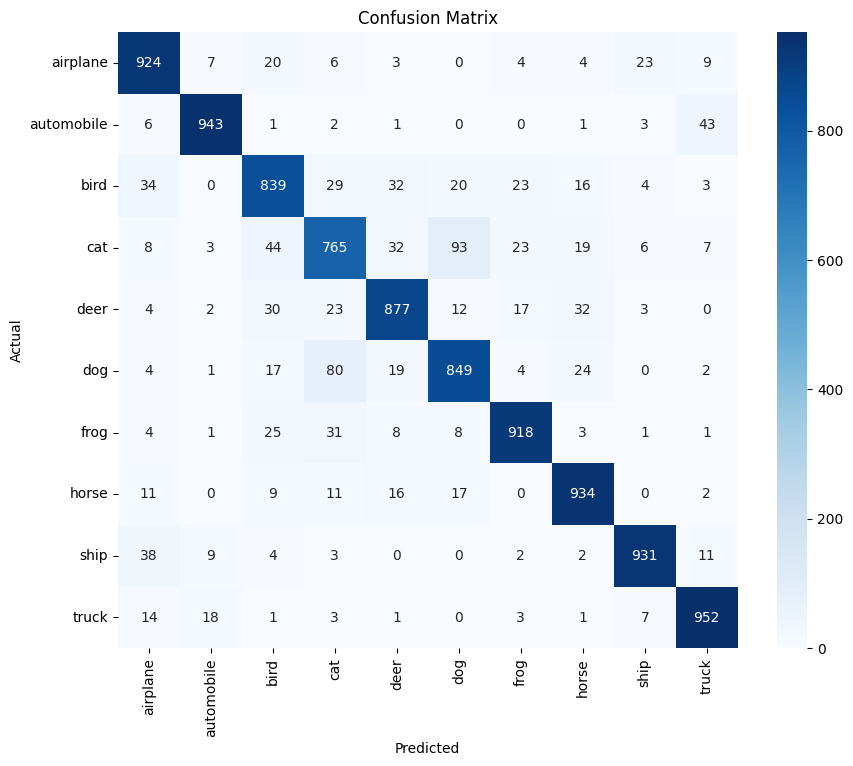

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

import seaborn as sns

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=train_dataset.classes,

    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


# ROC CURVE WITH AUC SCORE

y_true shape : (10000, 10)
y_score shape: (10000, 10)


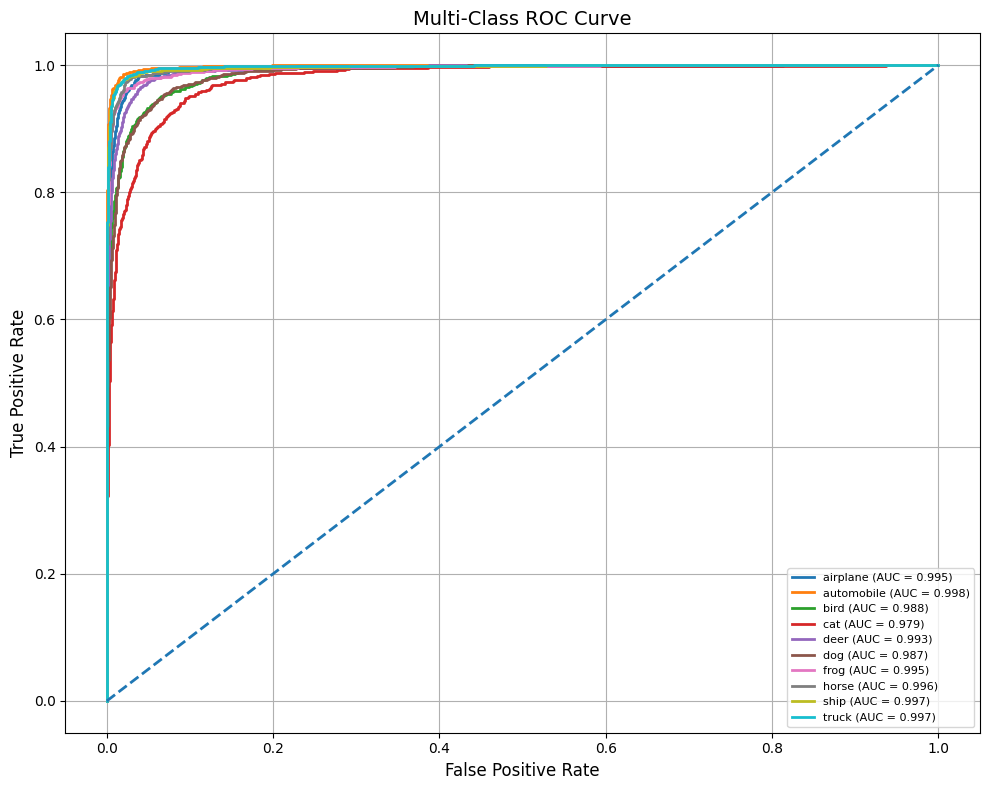

AUC SCORES
Macro AUC    : 0.9924
Weighted AUC : 0.9924


In [ ]:

import numpy as np

from sklearn.preprocessing import label_binarize

from sklearn.metrics import (
    roc_curve,
    auc,
    roc_auc_score
)



all_probs = []
all_preds = []
all_labels = []

model_cnn.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model_cnn(images)

        probs = torch.softmax(
            outputs,
            dim=1
        )

        _, preds = torch.max(
            probs,
            dim=1
        )

        all_probs.extend(
            probs.cpu().numpy()
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

# CONVERT TO NUMPY

y_true = label_binarize(
    all_labels,
    classes=np.arange(NUM_CLASSES)
)

y_score = np.array(all_probs)

print("y_true shape :", y_true.shape)
print("y_score shape:", y_score.shape)

# Expected:
# y_true shape : (N, NUM_CLASSES)
# y_score shape: (N, NUM_CLASSES)

# ROC CURVE


plt.figure(figsize=(10,8))

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(
        y_true[:, i],
        y_score[:, i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{train_dataset.classes[i]} "
              f"(AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.title(
    "Multi-Class ROC Curve",
    fontsize=14
)

plt.legend(
    loc="lower right",
    fontsize=8
)

plt.grid(True)

plt.tight_layout()

plt.show()


# MACRO & WEIGHTED AUC


auc_macro = roc_auc_score(
    y_true,
    y_score,
    multi_class="ovr",
    average="macro"
)

auc_weighted = roc_auc_score(
    y_true,
    y_score,
    multi_class="ovr",
    average="weighted"
)

print("AUC SCORES")


print(
    f"Macro AUC    : {auc_macro:.4f}"
)

print(
    f"Weighted AUC : {auc_weighted:.4f}"
)